<a target="_blank" href="https://colab.research.google.com/github/bmalcover/AppOC/blob/main/docs/notebooks/03_Series/01_Introduccio.ipynb">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>

# Introduction to Time Series

A time series is a sequence of values ordered in time. Unlike the datasets we worked with in previous blocks, where samples were independent of each other, in a time series the order matters: the value at time $t$ depends on previous values: $t-1, t-2, \ldots, t-n$.


## Basic Concepts

Below we list the basic concepts when working with time series:

- **Trend**: Long-term variation of the series. It can be increasing, decreasing, or absent.

- **Seasonality**: Patterns that repeat at a fixed frequency (daily, monthly, yearly...). For example, air temperature is systematically higher in summer and lower in winter.

- **Noise**: Random variation that cannot be explained by trend or seasonality.

- **Stationarity**: A series is stationary when its mean, variance, and autocorrelation structure do not change over time. Most statistical and deep learning models assume stationarity or require the series to be transformed to achieve it. A model trained on a non-stationary series may learn patterns that will not repeat in the future, leading to incorrect predictions.

Most statistical time series models assume that the series can be decomposed into trend, seasonality, and noise through addition ($y_t = T_t + S_t + \epsilon_t$) or multiplication ($y_t = T_t \cdot S_t \cdot \epsilon_t$). The additive model is appropriate when the amplitude of seasonality is constant, while the multiplicative model is more suitable when seasonality grows proportionally with the trend.


We will use the **Air Passengers** dataset from `statsmodels`, to illustrate the main concepts. It contains the monthly number of airline passengers in the United States between 1949 and 1960. It is a classic example of a time series with a clear upward trend and annual seasonality.


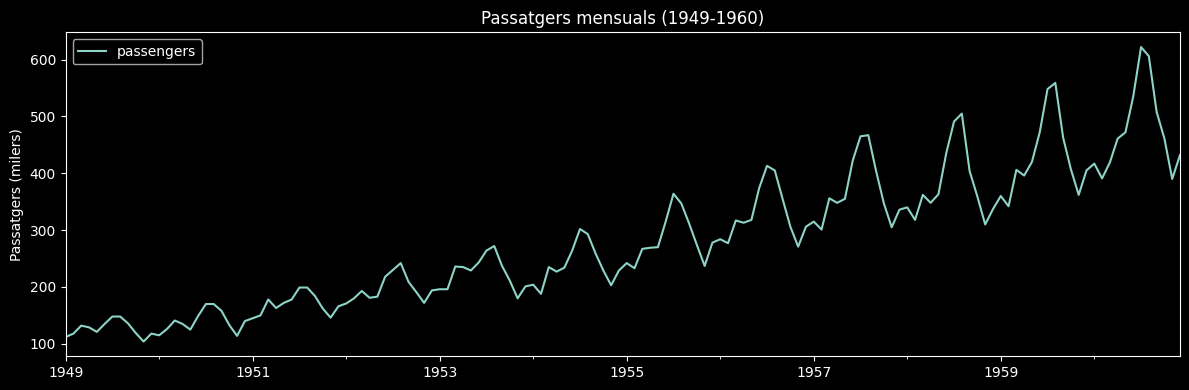

In [1]:

import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm

# Càrrega del dataset
data = sm.datasets.get_rdataset("AirPassengers", "datasets").data
data.columns = ['time', 'passengers']
data.index = pd.date_range(start='1949-01', periods=len(data), freq='ME')
data = data[['passengers']]

# Visualització
data.plot(figsize=(12, 4), title='Passatgers mensuals (1949-1960)')
plt.ylabel('Passatgers (milers)')
plt.tight_layout()
plt.show()

The next code illustrates the decomposition of a time series in Trend, Seasonality and Noise:

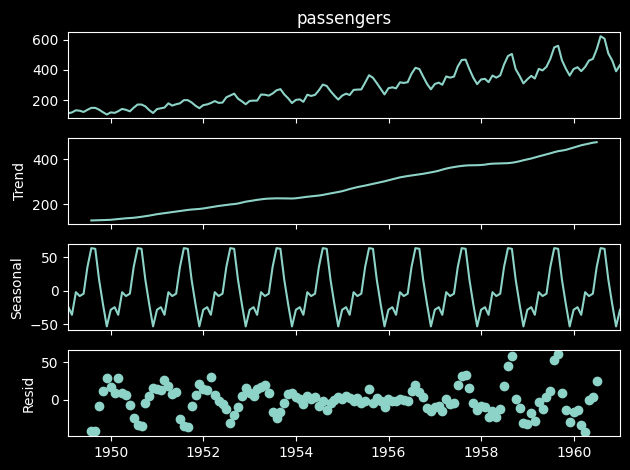

In [4]:
from statsmodels.tsa.seasonal import seasonal_decompose

decomposition = seasonal_decompose(data['passengers'], model='additive')
decomposition.plot()
plt.tight_layout()
plt.show()



## Evaluation Metrics

In regression problems on time series, the same metrics as in conventional regression are used, but it is important to consider that temporal scales and units of measurement influence their interpretation.

- Mean Absolute Error (MAE): average error in the original units, robust to outliers and easy to interpret. $$\text{MAE} = \frac{1}{n} \sum_{i=1}^{n} |y_i - \hat{y}_i|.$$

- Root Mean Squared Error (RMSE): penalises large errors more than MAE. Same unit as the target variable. $$\text{RMSE} = \sqrt{\frac{1}{n} \sum_{i=1}^{n} (y_i - \hat{y}_i)^2}.$$

- Mean Absolute Percentage Error (MAPE): percentage error, independent of scale. Useful for comparing models on series with very different magnitudes. Problematic when $y_i \approx 0$. $$\text{MAPE} = \frac{100}{n} \sum_{i=1}^{n} \left| \frac{y_i - \hat{y}_i}{y_i} \right|.$$

The choice of metric depends on the context of the problem. MAE is the most intuitive option when a direct interpretation of the error in the original units is desired. RMSE is more appropriate when large errors are especially undesirable, as it penalizes them quadratically. Finally, MAPE is useful when comparing model performance across datasets or scales, as it expresses the error as a percentage and is independent of the magnitude of the target variable.

For classification problems, we will use the metrics from the two previous modules.


## Classical Models with `statsmodels`

Before neural networks, statistical models were the reference for working with time series. The `statsmodels` library has a module called *Time Series Analysis* that implements the most common ones and is a good starting point for understanding data structure. Although we will not use this library extensively in this course, its ease of use, comparable to `scikit-learn`, may be of interest.

Link to [statsmodels](https://www.statsmodels.org/stable/user-guide.html#time-series-analysis).

Below we will find some usage examples that help us understand how it works:


### Rolling mean

The moving average smooths the series by calculating the average of the last $k$ values. It is useful for visualizing the trend and removing noise.

$$\hat{y}_t = \frac{1}{k} \sum_{i=0}^{k-1} y_{t-i}$$

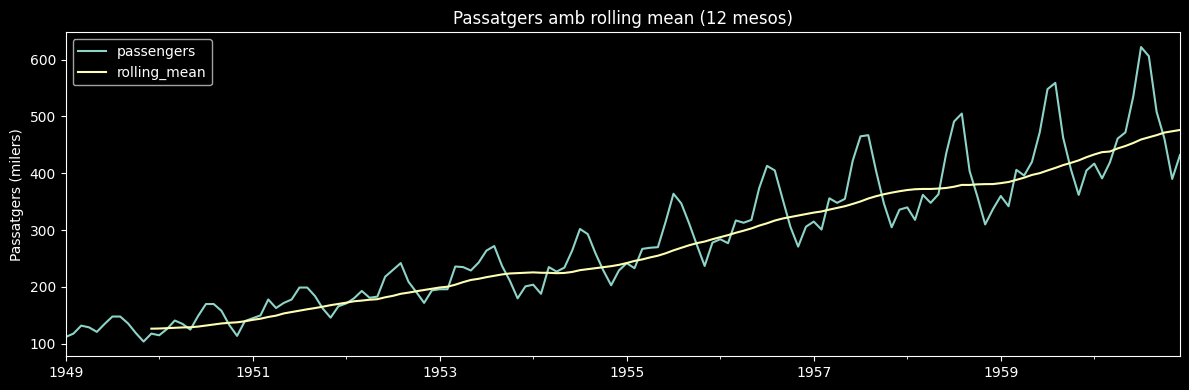

In [2]:
# Rolling mean amb finestra de 12 mesos
data['rolling_mean'] = data['passengers'].rolling(window=12).mean()

data.plot(figsize=(12, 4), title='Passatgers amb rolling mean (12 mesos)')
plt.ylabel('Passatgers (milers)')
plt.tight_layout()
plt.show()

### ARIMA Model

We will now see how to apply ARIMA (*AutoRegressive Integrated Moving Average*), a classical statistical model that combines three components:

- **AR (AutoRegressive):** the prediction depends on past values of the series.
- **I (Integrated):** differencing of the series to achieve stationarity.
- **MA (Moving Average):** the prediction depends on past errors of the model.

It is specified with three parameters $(p, d, q)$: autoregressive order, degree of differencing, and moving average order.

- $p$ is the autoregressive order (AR): indicates how many past values of the series are used to make the prediction. A value of $p=2$ means that the prediction at $t$ depends on the values at $t-1$ and $t-2$. Typical values: between 0 and 5. A value of $p=0$ removes the autoregressive component.

- $d$ is the degree of differencing (I): indicates how many times the series must be differenced to achieve stationarity. Differencing means computing $y_t - y_{t-1}$, i.e., working with the changes rather than the absolute values. A value of $d=0$ means the series is already stationary, $d=1$ is the most common case, and it is rarely necessary to go beyond $d=2$.

- $q$ is the moving average order (MA): indicates how many past prediction errors are incorporated into the model. A value of $q=2$ means that the prediction at $t$ takes into account the errors made at $t-1$ and $t-2$. Typical values: between 0 and 5. A value of $q=0$ removes the moving average component.

MAE:  63.55
RMSE: 82.51
MAPE: 14.22%


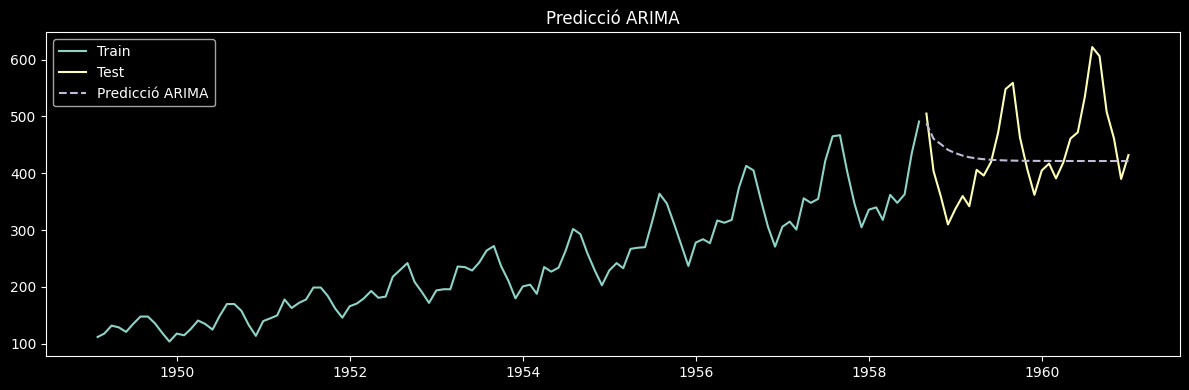

In [5]:
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_absolute_error
import numpy as np

# Divisió train/test (80/20)
train = data['passengers'][:int(len(data) * 0.8)]
test  = data['passengers'][int(len(data) * 0.8):]

# Entrenament del model ARIMA(2,1,2)
model = ARIMA(train, order=(2, 1, 2))
result = model.fit()

# Predicció
predictions = result.forecast(steps=len(test))

# Avaluació
mae  = mean_absolute_error(test, predictions)
rmse = np.sqrt(np.mean((test.values - predictions.values) ** 2))
mape = np.mean(np.abs((test.values - predictions.values) / test.values)) * 100

print(f"MAE:  {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"MAPE: {mape:.2f}%")

# Visualització
plt.figure(figsize=(12, 4))
plt.plot(train.index, train, label='Train')
plt.plot(test.index, test, label='Test')
plt.plot(test.index, predictions, label='Predicció ARIMA', linestyle='--')
plt.legend()
plt.title('Predicció ARIMA')
plt.tight_layout()
plt.show()

## Classical ML Applied to Time Series

The models from the first two blocks of the course (Random Forest, SVM, MLP) are not designed for time series, but can be adapted using a technique called **sliding window**: the series is transformed into a conventional regression problem by generating, for each time step $t$, a feature vector with the previous $k$ values as follows: $[y_{t-k}, y_{t-k+1}, \ldots, y_{t-1}] \rightarrow \hat{y}_t$.

In [6]:
import numpy as np

def create_sliding_window(series, window_size):
    X, y = [], []
    for i in range(window_size, len(series)):
        X.append(series[i-window_size:i])
        y.append(series[i])
    return np.array(X), np.array(y)

values = data['passengers'].values
X, y = create_sliding_window(values, window_size=12)

### Exercise

In previous sections we have used classical statistical models such as ARIMA to predict the number of airline passengers. In this exercise we will use a `RandomForestRegressor` as an alternative approach. A Random Forest regressor is an ensemble model that combines multiple decision trees, each trained on a random subset of the data and features, and averages their predictions to produce a final output.

Using the Air Passengers dataset and the sliding window prepared in the previous section, train a Random Forest model and evaluate it using MAE. Compare the results with those obtained by ARIMA. Which model performs better?

In [12]:
X_train = X[:int(len(data) * 0.8)]
X_test  = X[int(len(data) * 0.8):]

y_train = y[:int(len(data) * 0.8)]
y_test = y[int(len(data) * 0.8):]


In [15]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error
import numpy as np

# Entrenament
rf = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)

# Predicció
y_pred = rf.predict(X_test)

# Avaluació
mae  = mean_absolute_error(y_test, y_pred)

print(f"MAE:  {mae:.4f}")


MAE:  31.4882
RMSE: 43.0427
MAPE: 6.38%


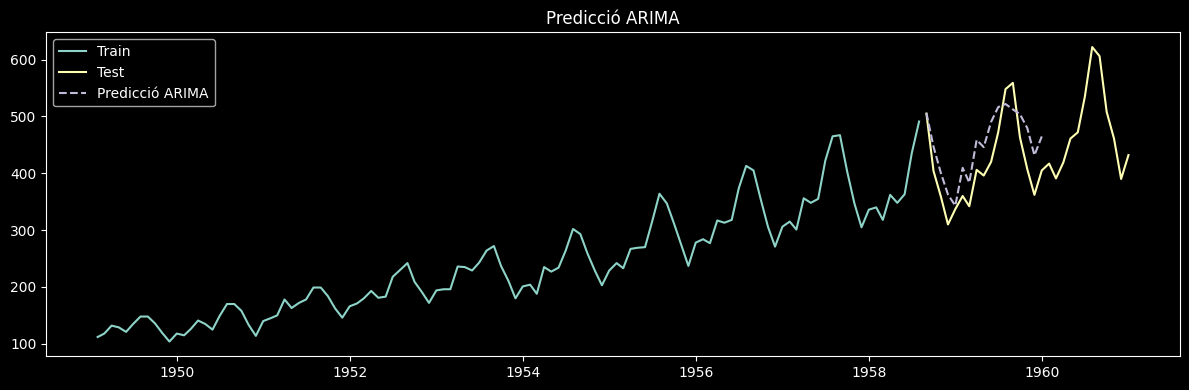

In [28]:
# Visualització
plt.figure(figsize=(12, 4))
plt.plot(train.index, train, label='Train')
plt.plot(test.index, test, label='Test')
plt.plot(test.index[:17], y_pred, label='Predicció ARIMA', linestyle='--')
plt.legend()
plt.title('Predicció ARIMA')
plt.tight_layout()
plt.show()

Although the sliding window approach allows classical ML models to be applied to time series, it has an important limitation: the train/test split cannot be done randomly as in previous blocks, since mixing future data with past data during training would introduce information that the model could not have available in a real case. For this reason, the split must always be done sequentially, respecting the temporal order of the data.